In [50]:
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn import preprocessing
from sklearn.feature_selection import VarianceThreshold

#Machine Learning classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree
from sklearn.decomposition import PCA
# Plotting modules
from pandas.plotting import scatter_matrix
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns


### Helper Functions 

In [51]:
def print_unique_values(df, df_name):
    print(f"\n--- Unique values in {df_name} ---")
    for col in df.columns:
        unique_vals = df[col].unique()
        print(f"{col} ({len(unique_vals)} unique): {unique_vals[:10]}{'...' if len(unique_vals) > 10 else ''}")
        
def print_columns(df, name):
    print(f"\n{name} Columns ({len(df.columns)}):")
    print(df.columns.tolist())

def print_data_types(df, name):
    print(f"\n{name} Column Data Types:")
    print(df.dtypes)

def clean_column_names(df):
    df.columns = df.columns.str.strip() \
                           .str.lower() \
                           .str.replace(r'\s+', '_', regex=True) \
                           .str.replace(r'[^\w_]', '', regex=True)  # remove special characters
    return df



### Reading data

In [52]:
categorical_df = pd.read_excel(r"F:\GUC\sem 10\(NETW 1013) Machine Learning\projects\TRAIN_NEW\TRAIN_CATEGORICAL_METADATA_new.xlsx")
numerical_df = pd.read_excel(r"F:\GUC\sem 10\(NETW 1013) Machine Learning\projects\TRAIN_NEW\TRAIN_QUANTITATIVE_METADATA_new.xlsx")
matrices_df = pd.read_csv(r"F:\GUC\sem 10\(NETW 1013) Machine Learning\projects\TRAIN_NEW\TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")
solutions_df = pd.read_excel(r"F:\GUC\sem 10\(NETW 1013) Machine Learning\projects\TRAIN_NEW\TRAINING_SOLUTIONS.xlsx")

### EDA and Data cleaning

In [53]:
categorical_df = clean_column_names(categorical_df)
numerical_df = clean_column_names(numerical_df)
matrices_df = clean_column_names(matrices_df)
solutions_df = clean_column_names(solutions_df)

In [54]:
for df in [categorical_df, numerical_df, matrices_df, solutions_df]:
    if 'participant_id' in df.columns:
        df.set_index('participant_id', inplace=True)

In [55]:
print_data_types(categorical_df, "Categorical Metadata")
print_data_types(numerical_df, "Quantitative Metadata")
print_data_types(matrices_df, "Connectome Matrices")
print_data_types(solutions_df, "Solutions")


Categorical Metadata Column Data Types:
basic_demos_enroll_year               int64
basic_demos_study_site                int64
preint_demos_fam_child_ethnicity    float64
preint_demos_fam_child_race         float64
mri_track_scan_location             float64
barratt_barratt_p1_edu              float64
barratt_barratt_p1_occ              float64
barratt_barratt_p2_edu              float64
barratt_barratt_p2_occ              float64
dtype: object

Quantitative Metadata Column Data Types:
ehq_ehq_total                 float64
colorvision_cv_score          float64
apq_p_apq_p_cp                float64
apq_p_apq_p_id                float64
apq_p_apq_p_inv               float64
apq_p_apq_p_opd               float64
apq_p_apq_p_pm                float64
apq_p_apq_p_pp                float64
sdq_sdq_conduct_problems      float64
sdq_sdq_difficulties_total    float64
sdq_sdq_emotional_problems    float64
sdq_sdq_externalizing         float64
sdq_sdq_generating_impact     float64
sdq_sdq_hyper

In [56]:
print_unique_values(categorical_df, "Categorical Metadata")
print_unique_values(numerical_df, "Quantitative Metadata")
print_unique_values(matrices_df, "Connectome Matrices")
print_unique_values(solutions_df, "Solutions")


--- Unique values in Categorical Metadata ---
basic_demos_enroll_year (6 unique): [2019 2017 2018 2016 2015 2020]
basic_demos_study_site (4 unique): [4 1 2 3]
preint_demos_fam_child_ethnicity (5 unique): [ 1.  0.  3.  2. nan]
preint_demos_fam_child_race (11 unique): [ 0.  9.  2.  8.  1. 10.  4. nan  3. 11.]...
mri_track_scan_location (5 unique): [ 3.  2.  1.  4. nan]
barratt_barratt_p1_edu (8 unique): [21.  9. 18. 12. 15.  3. nan  6.]
barratt_barratt_p1_occ (11 unique): [45.  0. 10. 25. 35. nan 30. 40. 15.  5.]...
barratt_barratt_p2_edu (8 unique): [nan 21. 18. 15.  9. 12.  6.  3.]
barratt_barratt_p2_occ (11 unique): [nan 45.  0. 40. 30. 15. 35.  5. 10. 20.]...

--- Unique values in Quantitative Metadata ---
ehq_ehq_total (159 unique): [ 100.     92.27   86.67   93.34    0.   -100.     73.34   31.13  -23.33
   87.8 ]...
colorvision_cv_score (15 unique): [13. 14.  0. nan 12.  3. 11.  9. 10.  5.]...
apq_p_apq_p_cp (11 unique): [ 3.  8.  5.  4.  6.  2.  7. nan 12.  9.]...
apq_p_apq_p_id 

In [57]:
df = categorical_df.join([numerical_df, matrices_df, solutions_df], how='inner')

In [58]:
print(f"Shape of df: {df.shape} (rows, columns)")

Shape of df: (1213, 19929) (rows, columns)


In [59]:
# handling duplicates"  no duplicates :(  "
df = df.drop_duplicates()
df = df.loc[:, ~df.T.duplicated()]

In [60]:
print(f"Shape of df: {df.shape} (rows, columns)")

Shape of df: (1213, 19929) (rows, columns)


In [61]:
#Handling missing 
missing_percent = df.isnull().mean() * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

mri_track_age_at_scan               29.678483
barratt_barratt_p2_occ              18.301731
barratt_barratt_p2_edu              16.323166
preint_demos_fam_child_race          4.451772
preint_demos_fam_child_ethnicity     3.544930
barratt_barratt_p1_occ               2.555647
colorvision_cv_score                 1.896125
barratt_barratt_p1_edu               1.236603
ehq_ehq_total                        1.071723
apq_p_apq_p_pm                       0.989283
apq_p_apq_p_pp                       0.989283
apq_p_apq_p_opd                      0.989283
apq_p_apq_p_inv                      0.989283
apq_p_apq_p_id                       0.989283
apq_p_apq_p_cp                       0.989283
sdq_sdq_difficulties_total           0.741962
sdq_sdq_emotional_problems           0.741962
sdq_sdq_externalizing                0.741962
sdq_sdq_generating_impact            0.741962
sdq_sdq_hyperactivity                0.741962
sdq_sdq_internalizing                0.741962
sdq_sdq_peer_problems             

In [62]:
missing_cols = df.columns[df.isnull().any()]
df[missing_cols] = df[missing_cols].fillna(df[missing_cols].median())
print(df.isnull().sum())

basic_demos_enroll_year             0
basic_demos_study_site              0
preint_demos_fam_child_ethnicity    0
preint_demos_fam_child_race         0
mri_track_scan_location             0
                                   ..
197throw_198thcolumn                0
197throw_199thcolumn                0
198throw_199thcolumn                0
adhd_outcome                        0
sex_f                               0
Length: 19929, dtype: int64


In [63]:
# Identify highly correlated pairs
#corr_matrix = df.corr().abs()
#upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop one of each pair with correlation > 0.95
#to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
#df.drop(columns=to_drop, inplace=True)


In [64]:
selector = VarianceThreshold(threshold=0.0)  # 0 removes columns with same value in all rows
selector.fit(df)
df = df[df.columns[selector.get_support(indices=True)]]
print(f"Shape of df: {df.shape} (rows, columns)")

Shape of df: (1213, 19929) (rows, columns)


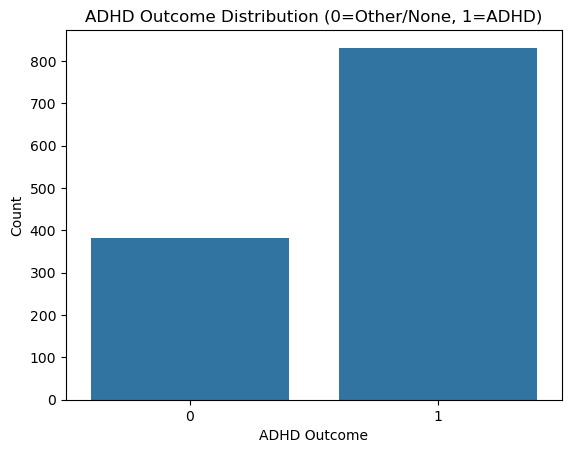

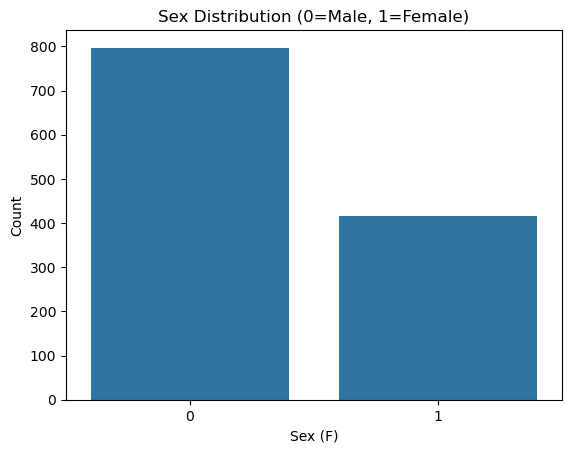

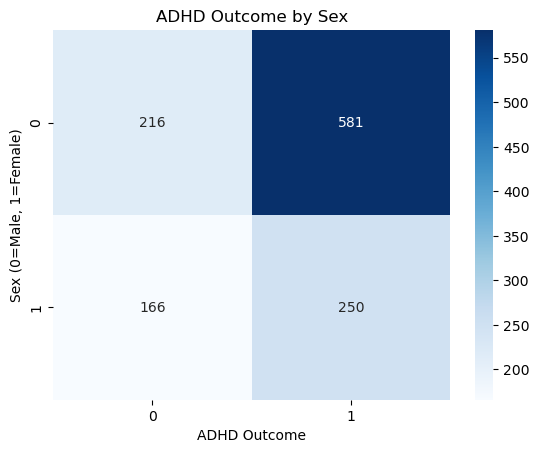

In [65]:
# ADHD Diagnosis Distribution
sns.countplot(x='adhd_outcome', data=df)
plt.title('ADHD Outcome Distribution (0=Other/None, 1=ADHD)')
plt.xlabel('ADHD Outcome')
plt.ylabel('Count')
plt.show()

# Sex Distribution
sns.countplot(x='sex_f', data=df)
plt.title('Sex Distribution (0=Male, 1=Female)')
plt.xlabel('Sex (F)')
plt.ylabel('Count')
plt.show()

cross_tab = pd.crosstab(df['sex_f'], df['adhd_outcome'])

sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('ADHD Outcome by Sex')
plt.xlabel('ADHD Outcome')
plt.ylabel('Sex (0=Male, 1=Female)')
plt.show()

In [66]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index([], dtype='object')


##### df_combined

In [67]:
df_combined = df.copy()
# Combine 'sex_f' and 'adhd_outcome' into one column
df_combined['sex_adhd'] = (df_combined['sex_f'] * 2) + df_combined['adhd_outcome']
df_combined.drop(columns=['sex_f', 'adhd_outcome'], inplace=True)


# Count occurrences of each value in 'sex_adhd'
print(df_combined['sex_adhd'].value_counts())


sex_adhd
1    581
3    250
0    216
2    166
Name: count, dtype: int64


#### Do not rerun

In [68]:
# Add the target temporarily to your DataFrame
df_corr = df_combined.copy()

# Ensure all features are numeric (you’ve done this if you've encoded already)
correlations = df_corr.corr(numeric_only=True)

# Correlation of all features with the target
target_corr = correlations['sex_adhd'].drop(['sex_adhd'], errors='ignore')

# Sort by absolute value to see strongest correlations
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

# Print top features most correlated with the target
print(target_corr_sorted.head(20))


sdq_sdq_emotional_problems    0.197351
164throw_189thcolumn          0.178088
sdq_sdq_internalizing         0.172959
sdq_sdq_difficulties_total    0.171412
131throw_185thcolumn          0.169112
sdq_sdq_generating_impact     0.168372
131throw_189thcolumn          0.157411
57throw_189thcolumn           0.149907
76throw_131thcolumn           0.148539
131throw_170thcolumn          0.145850
80throw_185thcolumn           0.145235
131throw_194thcolumn          0.144255
131throw_184thcolumn          0.140739
131throw_191thcolumn          0.139442
63throw_131thcolumn           0.139114
184throw_185thcolumn          0.134594
75throw_131thcolumn           0.133739
114throw_159thcolumn          0.132905
131throw_179thcolumn          0.132569
191throw_197thcolumn          0.132548
Name: sex_adhd, dtype: float64


In [69]:
#Combined df
X = df_combined.drop(columns=['sex_adhd'])  # features
y = df_combined['sex_adhd']  


In [70]:
#Original df
X_df = df.drop(columns=['sex_f', 'adhd_outcome'])  # features
y_sex = df['sex_f']
y_adhd = df['adhd_outcome']

In [71]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)
print("Class distribution in y_resampled:")
print(pd.Series(y_resampled).value_counts())



Class distribution in y_resampled:
sex_adhd
1    581
2    581
3    581
0    581
Name: count, dtype: int64


In [72]:
pca = PCA(n_components=0.95)  
X_pca = pca.fit_transform(X_scaled)

In [73]:
# For model without PCA
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_scaled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

In [74]:

# For model with PCA
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)


In [75]:
#For original df
y_combined_strat = y_sex * 2 + y_adhd  # values 0 to 3

# 3. Apply SMOTE to X and the combined label
smote = SMOTE(random_state=42)
X_resampled_df, y_combined_resampled = smote.fit_resample(X_df, y_combined_strat)

# 4. Recover sex and ADHD from the combined label
y_sex_resampled = (y_combined_resampled // 2).astype(int)
y_adhd_resampled = (y_combined_resampled % 2).astype(int)

# 5. Apply PCA to the resampled features
pca = PCA(n_components=0.95, random_state=42)
X_pca_df = pca.fit_transform(X_resampled_df)

# 6. Scale the PCA-transformed data
scaler = StandardScaler()
X_scaled_df = scaler.fit_transform(X_pca_df)

# 7. Final train/test split
X_train_df, X_test_df, y_sex_train, y_sex_test, y_adhd_train, y_adhd_test = train_test_split(
    X_scaled_df, y_sex_resampled, y_adhd_resampled, 
    test_size=0.2, stratify=y_combined_resampled, random_state=42
)

In [76]:
print(pd.Series(y_test).value_counts())

sex_adhd
2    117
3    116
0    116
1    116
Name: count, dtype: int64


# <span style="color:red">KNN</span>  

###  <span style="color:pink">1st version combined without PCA  </span>  

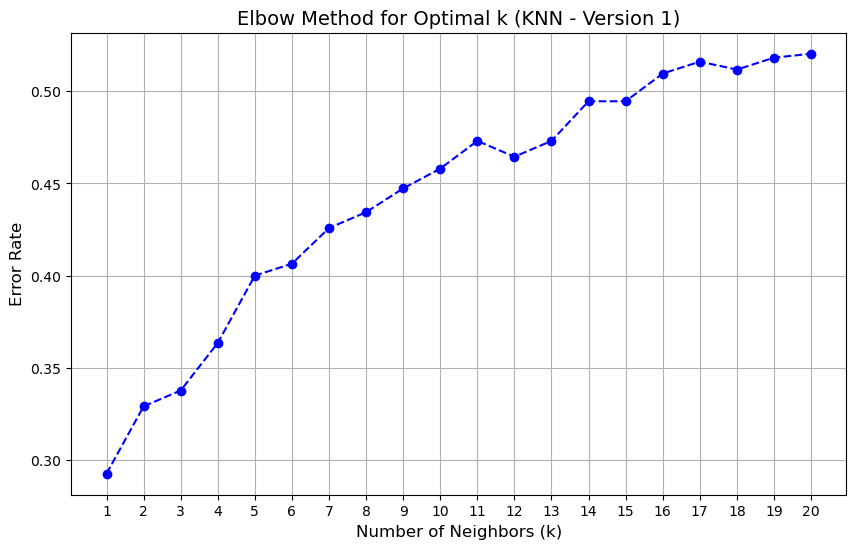

In [77]:

error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_full, y_train)
    y_pred = knn.predict(X_test_full)
    error = 1 - accuracy_score(y_test, y_pred)
    error_rates.append(error)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(k_range, error_rates, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k (KNN - Version 1)', fontsize=14)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Error Rate', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [78]:
# Define parameter grid
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create KNN model
knn = KNeighborsClassifier()

# Set up GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_full, y_train)

# Best k and performance
print("✅ Best k:", grid_search.best_params_['n_neighbors'])
print("✅ Best weights:", grid_search.best_params_['weights'])
print("✅ Best metric:", grid_search.best_params_['metric'])
print("🔍 Best Cross-Validation Accuracy: {:.4f}".format(grid_search.best_score_))

✅ Best k: 1
✅ Best weights: uniform
✅ Best metric: euclidean
🔍 Best Cross-Validation Accuracy: 0.7004


In [79]:
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_full)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\n📊 Classification Report on Test Set:")
print(classification_report(y_test, y_pred))




📊 Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.66      0.92      0.77       116
           1       0.00      0.00      0.00       116
           2       0.70      0.99      0.82       117
           3       0.77      0.91      0.83       116

    accuracy                           0.71       465
   macro avg       0.53      0.71      0.61       465
weighted avg       0.53      0.71      0.61       465



E:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
E:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
E:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.81      0.66       116
           1       0.00      0.00      0.00       116
           2       0.57      0.95      0.71       117
           3       0.76      0.64      0.69       116

    accuracy                           0.60       465
   macro avg       0.47      0.60      0.51       465
weighted avg       0.47      0.60      0.51       465



E:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
E:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
E:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 800x600 with 0 Axes>

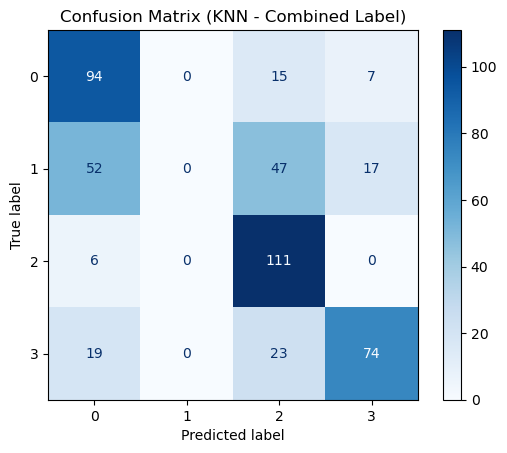

In [80]:
knn = KNeighborsClassifier(n_neighbors=5)  # You can tune k later
knn.fit(X_train_full, y_train)

# Predict on the test set
y_pred = knn.predict(X_test_full)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=2))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (KNN - Combined Label)")
plt.grid(False)
plt.show()

 ###  <span style="color:pink">2nd version combined with PCA </span>  

📊 Classification Report (KNN with PCA):
              precision    recall  f1-score   support

           0       0.53      0.84      0.65       116
           1       1.00      0.01      0.02       116
           2       0.60      0.95      0.74       117
           3       0.79      0.65      0.71       116

    accuracy                           0.61       465
   macro avg       0.73      0.61      0.53       465
weighted avg       0.73      0.61      0.53       465



<Figure size 800x600 with 0 Axes>

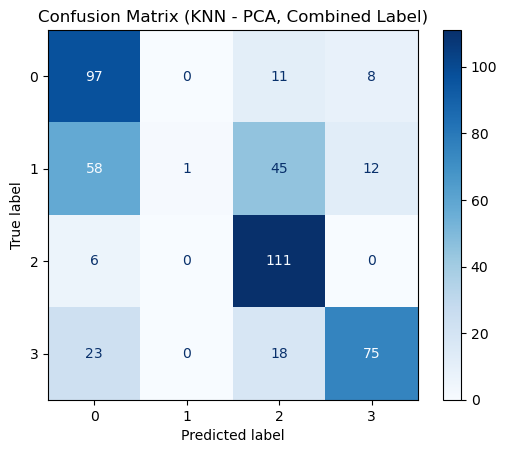

In [81]:
knn = KNeighborsClassifier(n_neighbors=5)  # You can optimize k later
knn.fit(X_train_pca, y_train)

# 2. Predict on test set
y_pred_pca = knn.predict(X_test_pca)

# 3. Classification Report
print("📊 Classification Report (KNN with PCA):")
print(classification_report(y_test, y_pred_pca, digits=2))

# 4. Confusion Matrix
cm_pca = confusion_matrix(y_test, y_pred_pca)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (KNN - PCA, Combined Label)")
plt.grid(False)
plt.show()

###  <span style="color:pink">3rd version 2 separate columns </span>  

Classification Report for Sex:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82       232
           1       0.81      0.86      0.83       233

    accuracy                           0.83       465
   macro avg       0.83      0.83      0.83       465
weighted avg       0.83      0.83      0.83       465


Classification Report for ADHD:
              precision    recall  f1-score   support

           0       0.68      0.99      0.80       233
           1       0.98      0.53      0.68       232

    accuracy                           0.76       465
   macro avg       0.83      0.76      0.74       465
weighted avg       0.83      0.76      0.74       465



<Figure size 800x600 with 0 Axes>

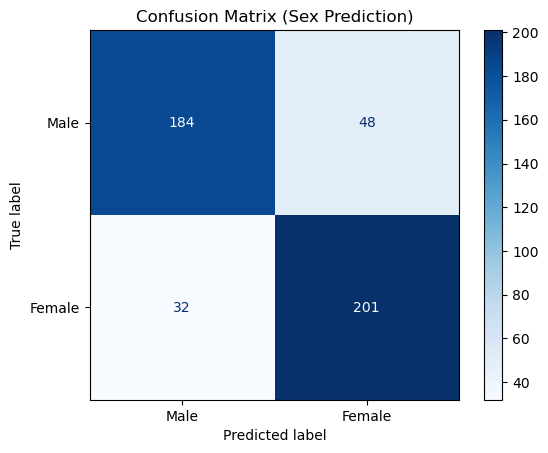

<Figure size 800x600 with 0 Axes>

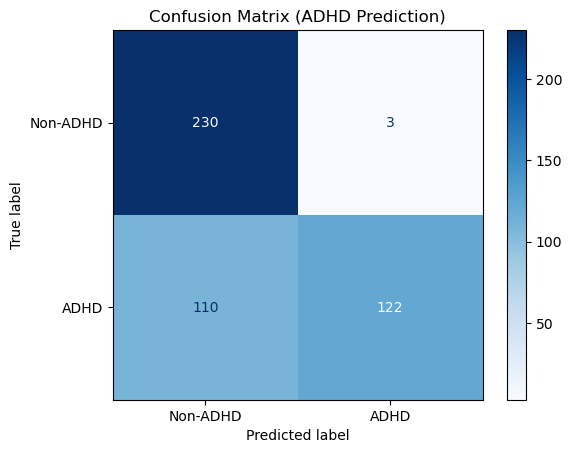

In [82]:
# Combine y_sex_train and y_adhd_train into a 2D array
base_knn = KNeighborsClassifier(n_neighbors=5)
multi_target_knn = MultiOutputClassifier(base_knn)

y_train_combined = np.column_stack((y_sex_train, y_adhd_train))

# Now fit the model with the combined target array
multi_target_knn.fit(X_train_df, y_train_combined)

# Predict on the test set
y_pred_sex_adhd = multi_target_knn.predict(X_test_df)

# Separate predictions for sex and ADHD
y_pred_sex = y_pred_sex_adhd[:, 0]  # Sex predictions
y_pred_adhd = y_pred_sex_adhd[:, 1]  # ADHD predictions

# Classification Report
print("Classification Report for Sex:")
print(classification_report(y_sex_test, y_pred_sex, digits=2))

print("\nClassification Report for ADHD:")
print(classification_report(y_adhd_test, y_pred_adhd, digits=2))

# Confusion Matrix for Sex
cm_sex = confusion_matrix(y_sex_test, y_pred_sex)
disp_sex = ConfusionMatrixDisplay(confusion_matrix=cm_sex, display_labels=['Male', 'Female'])
plt.figure(figsize=(8, 6))
disp_sex.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (Sex Prediction)")
plt.grid(False)
plt.show()

# Confusion Matrix for ADHD
cm_adhd = confusion_matrix(y_adhd_test, y_pred_adhd)
disp_adhd = ConfusionMatrixDisplay(confusion_matrix=cm_adhd, display_labels=['Non-ADHD', 'ADHD'])
plt.figure(figsize=(8, 6))
disp_adhd.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix (ADHD Prediction)")
plt.grid(False)
plt.show()

#   <span style="color:red">Decision Trees</span>  

###  <span style="color:pink">1st version combined without PCA  </span>  

📊 Decision Tree – Combined Label (No PCA)
              precision    recall  f1-score   support

           0       0.59      0.57      0.58       116
           1       0.46      0.46      0.46       116
           2       0.71      0.76      0.73       117
           3       0.62      0.61      0.62       116

    accuracy                           0.60       465
   macro avg       0.60      0.60      0.60       465
weighted avg       0.60      0.60      0.60       465



<Figure size 800x600 with 0 Axes>

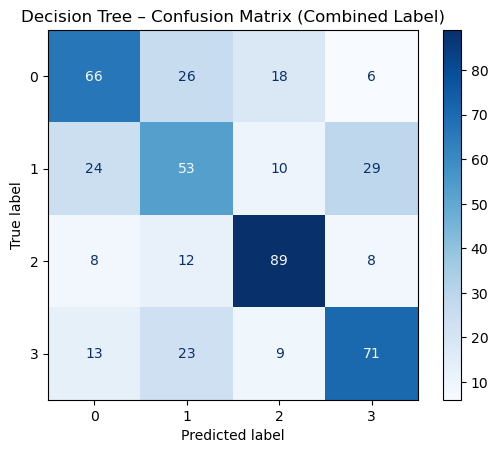

In [83]:
# X_train_full, X_test_full, y_train, y_test
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_full, y_train)

y_pred = dt.predict(X_test_full)

print("📊 Decision Tree – Combined Label (No PCA)")
print(classification_report(y_test, y_pred, digits=2))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Decision Tree – Confusion Matrix (Combined Label)")
plt.grid(False)
plt.show()

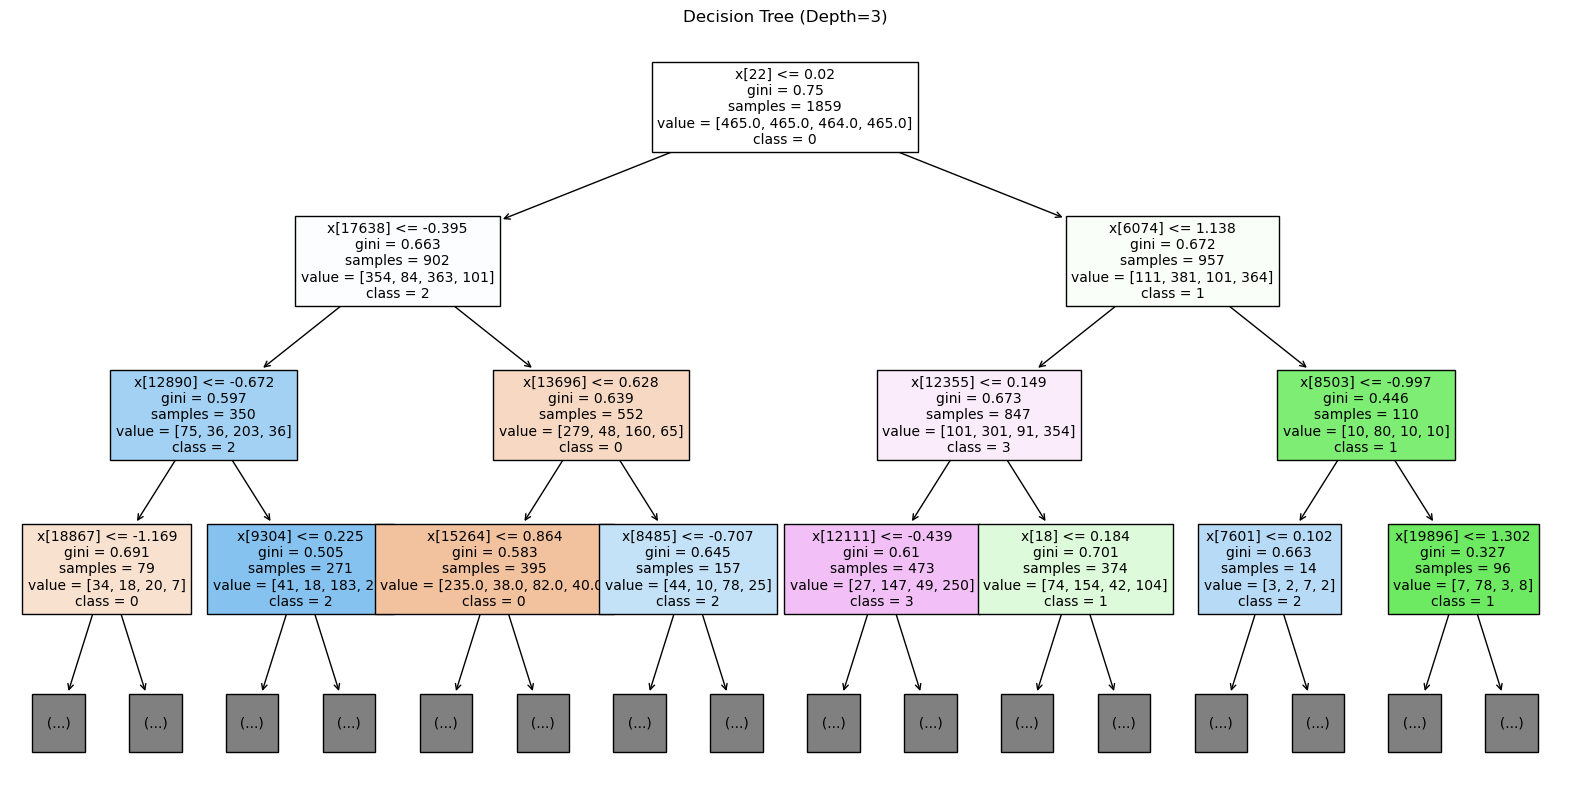

In [84]:
plt.figure(figsize=(20, 10))  # Increase size as needed
plot_tree(dt, 
          max_depth=3,            # Show only top 3 levels
          filled=True, 
          feature_names=None,     # You can set df.columns if needed
          class_names=['0', '1', '2', '3'], 
          fontsize=10)
plt.title("Decision Tree (Depth=3)")
plt.show()

 ###  <span style="color:pink">2nd version combined with PCA </span>  

📊 Decision Tree – Combined Label (With PCA)
              precision    recall  f1-score   support

           0       0.59      0.55      0.57       116
           1       0.56      0.53      0.54       116
           2       0.69      0.71      0.70       117
           3       0.52      0.57      0.54       116

    accuracy                           0.59       465
   macro avg       0.59      0.59      0.59       465
weighted avg       0.59      0.59      0.59       465



<Figure size 800x600 with 0 Axes>

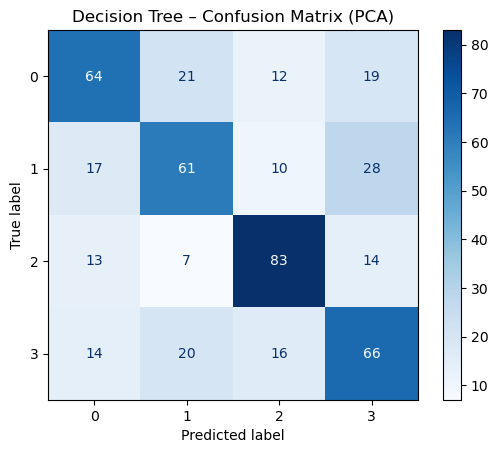

In [85]:
# X_train_pca, X_test_pca already split from X_pca and y_resampled

dt_pca = DecisionTreeClassifier(random_state=42)
dt_pca.fit(X_train_pca, y_train)

y_pred_pca = dt_pca.predict(X_test_pca)

print("📊 Decision Tree – Combined Label (With PCA)")
print(classification_report(y_test, y_pred_pca, digits=2))

cm_pca = confusion_matrix(y_test, y_pred_pca)
disp_pca = ConfusionMatrixDisplay(cm_pca, display_labels=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
disp_pca.plot(cmap='Blues', values_format='d')
plt.title("Decision Tree – Confusion Matrix (PCA)")
plt.grid(False)
plt.show()

###  <span style="color:pink">3rd version 2 separate columns </span>  

📊 Decision Tree – Multi-Target (Sex)
              precision    recall  f1-score   support

           0       0.76      0.72      0.74       232
           1       0.73      0.77      0.75       233

    accuracy                           0.74       465
   macro avg       0.74      0.74      0.74       465
weighted avg       0.74      0.74      0.74       465


📊 Decision Tree – Multi-Target (ADHD)
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       233
           1       0.77      0.78      0.77       232

    accuracy                           0.77       465
   macro avg       0.77      0.77      0.77       465
weighted avg       0.77      0.77      0.77       465



<Figure size 800x600 with 0 Axes>

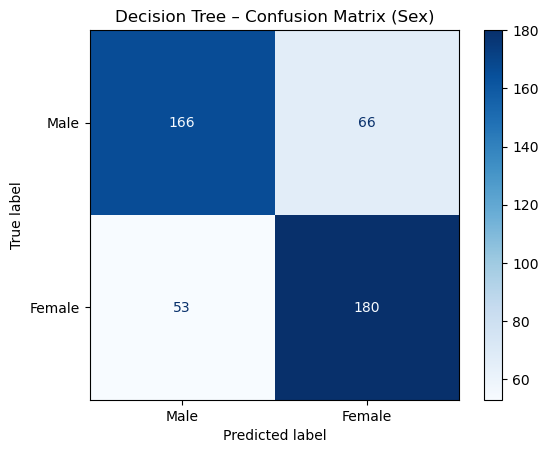

<Figure size 800x600 with 0 Axes>

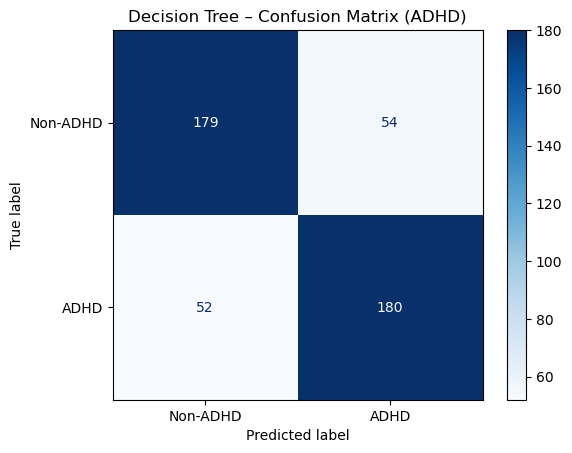

In [86]:
# Multi-target split: 
# X_train_df, X_test_df, y_sex_train, y_sex_test, y_adhd_train, y_adhd_test

from sklearn.multioutput import MultiOutputClassifier

y_train_combined = np.column_stack((y_sex_train, y_adhd_train))

dt_multi = MultiOutputClassifier(DecisionTreeClassifier(random_state=42))
dt_multi.fit(X_train_df, y_train_combined)

y_pred_multi = dt_multi.predict(X_test_df)
y_pred_sex = y_pred_multi[:, 0]
y_pred_adhd = y_pred_multi[:, 1]

# --- Evaluation ---
print("📊 Decision Tree – Multi-Target (Sex)")
print(classification_report(y_sex_test, y_pred_sex, digits=2))

print("\n📊 Decision Tree – Multi-Target (ADHD)")
print(classification_report(y_adhd_test, y_pred_adhd, digits=2))

# Confusion Matrices
cm_sex = confusion_matrix(y_sex_test, y_pred_sex)
disp_sex = ConfusionMatrixDisplay(cm_sex, display_labels=['Male', 'Female'])
plt.figure(figsize=(8, 6))
disp_sex.plot(cmap='Blues', values_format='d')
plt.title("Decision Tree – Confusion Matrix (Sex)")
plt.grid(False)
plt.show()

cm_adhd = confusion_matrix(y_adhd_test, y_pred_adhd)
disp_adhd = ConfusionMatrixDisplay(cm_adhd, display_labels=['Non-ADHD', 'ADHD'])
plt.figure(figsize=(8, 6))
disp_adhd.plot(cmap='Blues', values_format='d')
plt.title("Decision Tree – Confusion Matrix (ADHD)")
plt.grid(False)
plt.show()


#   <span style="color:red">Random Forests</span>  

###  <span style="color:pink">1st version combined without PCA  </span>  

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters from Grid Search:
{'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200}

📊 Random Forest – Best Model Performance (After Grid Search):
              precision    recall  f1-score   support

           0       0.98      0.78      0.87       116
           1       0.71      0.90      0.79       116
           2       0.97      0.96      0.97       117
           3       0.89      0.85      0.87       116

    accuracy                           0.87       465
   macro avg       0.89      0.87      0.87       465
weighted avg       0.89      0.87      0.87       465



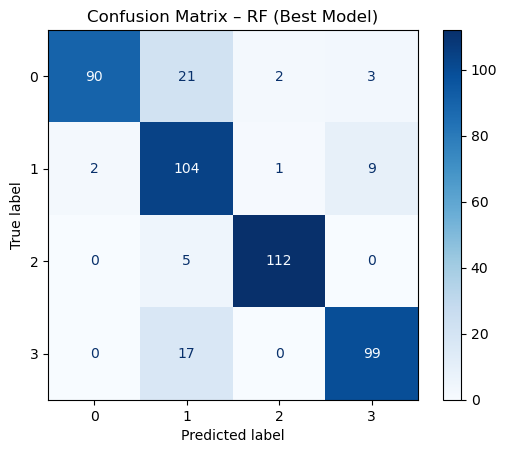

In [87]:
rf = RandomForestClassifier(random_state=42)

# Step 2: Define a reduced parameter grid for grid search
param_grid = {
    'n_estimators': [100, 150, 200],         # Number of trees
    'max_depth': [None, 10, 20, 30],         # Maximum depth of trees
    'min_samples_leaf': [1, 2, 4]            # Minimum samples at leaf node
}

# Step 3: Set up GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

# Step 4: Fit GridSearchCV to the data
grid_search.fit(X_train_full, y_train)

# Step 5: Print the best parameters found by GridSearchCV
print("Best Parameters from Grid Search:")
print(grid_search.best_params_)

# Step 6: Use the best parameters to create a new RandomForest model
best_rf = grid_search.best_estimator_

# Step 7: Train the model on the full training data and predict on the test set
best_rf.fit(X_train_full, y_train)
y_pred_rf = best_rf.predict(X_test_full)

# Step 8: Classification report and confusion matrix
print("\n📊 Random Forest – Best Model Performance (After Grid Search):")
print(classification_report(y_test, y_pred_rf, digits=2))

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1, 2, 3])
disp_rf.plot(cmap='Blues')
plt.title("Confusion Matrix – RF (Best Model)")
plt.grid(False)
plt.show()

 ###  <span style="color:pink">2nd version combined with PCA </span>  


📊 Random Forest – Version 2 (PCA Features):
              precision    recall  f1-score   support

           0       1.00      0.73      0.85       116
           1       0.67      0.97      0.79       116
           2       0.97      0.96      0.97       117
           3       0.95      0.78      0.86       116

    accuracy                           0.86       465
   macro avg       0.90      0.86      0.87       465
weighted avg       0.90      0.86      0.87       465



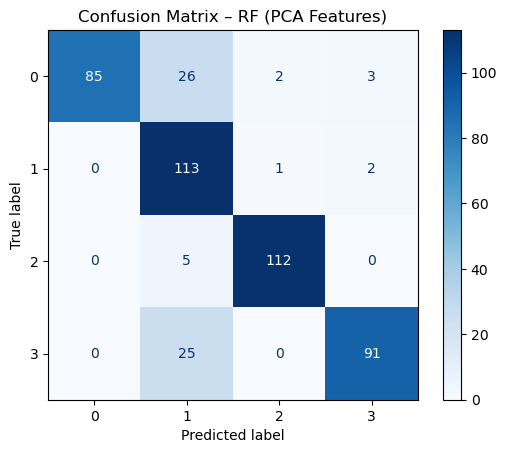

In [88]:
rf2 = RandomForestClassifier(n_estimators=200, random_state=42)
rf2.fit(X_train_pca, y_train)

# Predict on the test set
y_pred_rf2 = rf2.predict(X_test_pca)

# Classification report
print("\n📊 Random Forest – Version 2 (PCA Features):")
print(classification_report(y_test, y_pred_rf2, digits=2))

# Confusion matrix
cm2 = confusion_matrix(y_test, y_pred_rf2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=[0, 1, 2, 3])
disp2.plot(cmap='Blues')
plt.title("Confusion Matrix – RF (PCA Features)")
plt.grid(False)
plt.show()

###  <span style="color:pink">3rd version 2 separate columns </span>  

Classification Report for Sex (Version 3):
              precision    recall  f1-score   support

           0       0.91      0.94      0.93       232
           1       0.94      0.91      0.92       233

    accuracy                           0.92       465
   macro avg       0.93      0.92      0.92       465
weighted avg       0.93      0.92      0.92       465


Classification Report for ADHD (Version 3):
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       233
           1       0.89      0.92      0.90       232

    accuracy                           0.90       465
   macro avg       0.90      0.90      0.90       465
weighted avg       0.90      0.90      0.90       465



<Figure size 800x600 with 0 Axes>

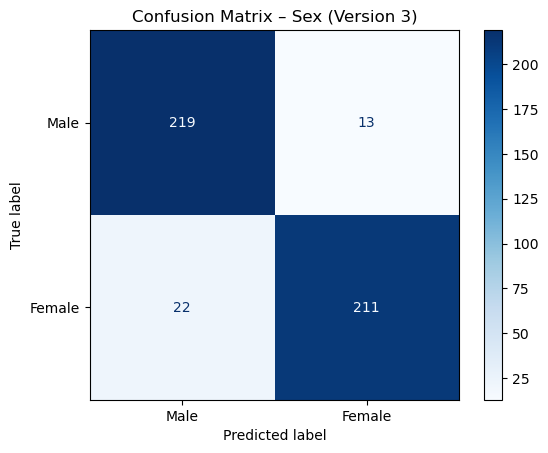

<Figure size 800x600 with 0 Axes>

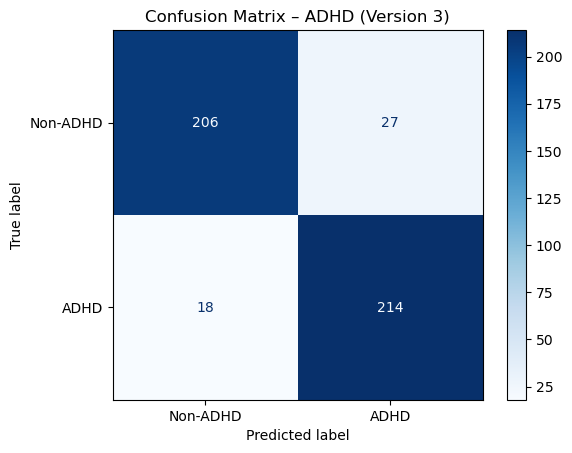

In [89]:
# Combine y_sex_train and y_adhd_train into a 2D array
y_train_combined = np.column_stack((y_sex_train, y_adhd_train))
y_test_combined = np.column_stack((y_sex_test, y_adhd_test))

# Train a Random Forest model for multi-output prediction
rf = RandomForestClassifier(n_estimators=200, random_state=42)

# Use MultiOutputClassifier to handle multi-target classification
multi_target_rf = MultiOutputClassifier(rf, n_jobs=-1)
multi_target_rf.fit(X_train_df, y_train_combined)

# Predict on the test set
y_pred_combined = multi_target_rf.predict(X_test_df)

# Separate predictions for sex and ADHD
y_pred_sex_rf = y_pred_combined[:, 0]  # Sex predictions
y_pred_adhd_rf = y_pred_combined[:, 1]  # ADHD predictions

# Classification Report for Sex
print("Classification Report for Sex (Version 3):")
print(classification_report(y_sex_test, y_pred_sex_rf, digits=2))

# Classification Report for ADHD
print("\nClassification Report for ADHD (Version 3):")
print(classification_report(y_adhd_test, y_pred_adhd_rf, digits=2))

# Confusion Matrix for Sex
cm_sex_rf = confusion_matrix(y_sex_test, y_pred_sex_rf)
disp_sex_rf = ConfusionMatrixDisplay(confusion_matrix=cm_sex_rf, display_labels=['Male', 'Female'])
plt.figure(figsize=(8, 6))
disp_sex_rf.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – Sex (Version 3)")
plt.grid(False)
plt.show()

# Confusion Matrix for ADHD
cm_adhd_rf = confusion_matrix(y_adhd_test, y_pred_adhd_rf)
disp_adhd_rf = ConfusionMatrixDisplay(confusion_matrix=cm_adhd_rf, display_labels=['Non-ADHD', 'ADHD'])
plt.figure(figsize=(8, 6))
disp_adhd_rf.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – ADHD (Version 3)")
plt.grid(False)
plt.show()

#   <span style="color:red">Logistic Regression</span>  

###  <span style="color:pink">1st version combined without PCA  </span>  

📊 Logistic Regression – Version 1 (Full Features):
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       116
           1       0.81      0.71      0.76       116
           2       0.90      0.99      0.94       117
           3       0.84      0.88      0.86       116

    accuracy                           0.85       465
   macro avg       0.85      0.85      0.85       465
weighted avg       0.85      0.85      0.85       465



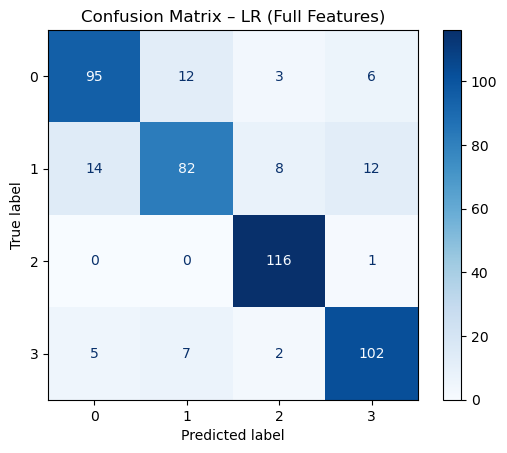

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Train
lr1 = LogisticRegression(max_iter=1000, random_state=42)
lr1.fit(X_train_full, y_train)

# Predict
y_pred_lr1 = lr1.predict(X_test_full)

# Evaluate
print("📊 Logistic Regression – Version 1 (Full Features):")
print(classification_report(y_test, y_pred_lr1, digits=2))

cm1 = confusion_matrix(y_test, y_pred_lr1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=[0, 1, 2, 3])
disp1.plot(cmap='Blues')
plt.title("Confusion Matrix – LR (Full Features)")
plt.grid(False)
plt.show()


 ###  <span style="color:pink">2nd version combined with PCA </span>  

📊 Logistic Regression – Version 2 (PCA):
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       116
           1       0.79      0.66      0.72       116
           2       0.94      0.99      0.96       117
           3       0.87      0.91      0.89       116

    accuracy                           0.85       465
   macro avg       0.85      0.85      0.85       465
weighted avg       0.85      0.85      0.85       465



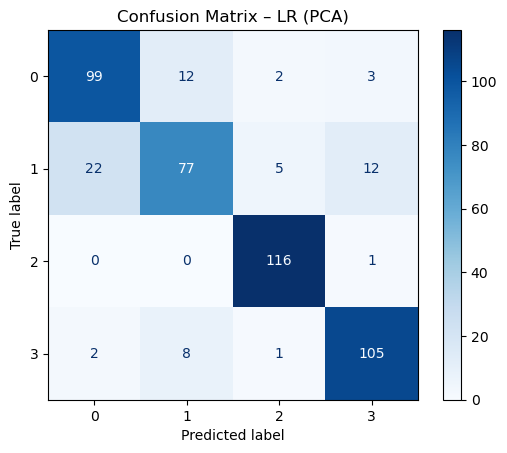

In [91]:
lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X_train_pca, y_train)

y_pred_lr2 = lr2.predict(X_test_pca)

print("📊 Logistic Regression – Version 2 (PCA):")
print(classification_report(y_test, y_pred_lr2, digits=2))

cm2 = confusion_matrix(y_test, y_pred_lr2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=[0, 1, 2, 3])
disp2.plot(cmap='Blues')
plt.title("Confusion Matrix – LR (PCA)")
plt.grid(False)
plt.show()


###  <span style="color:pink">3rd version 2 separate columns </span>  

📊 Logistic Regression – Version 3 (Sex):
              precision    recall  f1-score   support

           0       0.88      0.85      0.86       232
           1       0.86      0.88      0.87       233

    accuracy                           0.87       465
   macro avg       0.87      0.87      0.87       465
weighted avg       0.87      0.87      0.87       465


📊 Logistic Regression – Version 3 (ADHD):
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       233
           1       0.89      0.83      0.86       232

    accuracy                           0.86       465
   macro avg       0.86      0.86      0.86       465
weighted avg       0.86      0.86      0.86       465



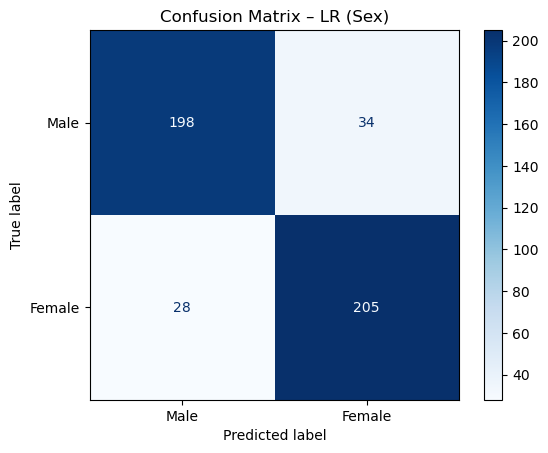

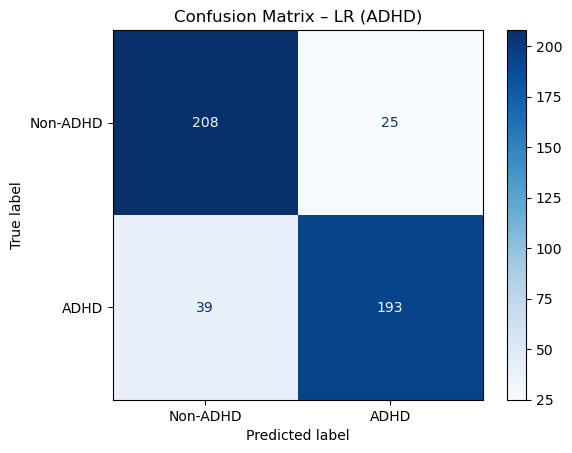

In [92]:
# Combine targets
y_train_combined = np.column_stack((y_sex_train, y_adhd_train))
y_test_combined = np.column_stack((y_sex_test, y_adhd_test))

# Multi-output logistic regression
multi_lr = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
multi_lr.fit(X_train_df, y_train_combined)

# Predict
y_pred_combined = multi_lr.predict(X_test_df)
y_pred_sex = y_pred_combined[:, 0]
y_pred_adhd = y_pred_combined[:, 1]

# Reports
print("📊 Logistic Regression – Version 3 (Sex):")
print(classification_report(y_sex_test, y_pred_sex, digits=2))

print("\n📊 Logistic Regression – Version 3 (ADHD):")
print(classification_report(y_adhd_test, y_pred_adhd, digits=2))

# Confusion Matrices
cm_sex = confusion_matrix(y_sex_test, y_pred_sex)
disp_sex = ConfusionMatrixDisplay(confusion_matrix=cm_sex, display_labels=['Male', 'Female'])
disp_sex.plot(cmap='Blues')
plt.title("Confusion Matrix – LR (Sex)")
plt.grid(False)
plt.show()

cm_adhd = confusion_matrix(y_adhd_test, y_pred_adhd)
disp_adhd = ConfusionMatrixDisplay(confusion_matrix=cm_adhd, display_labels=['Non-ADHD', 'ADHD'])
disp_adhd.plot(cmap='Blues')
plt.title("Confusion Matrix – LR (ADHD)")
plt.grid(False)
plt.show()